# Training visualization — PD

End-to-end view of every continued-pretraining trial that
`scripts/train_pipeline.py` has produced — per-epoch loss/metric
curves, learning-rate schedule, cross-trial comparisons,
convergence diagnostics, and resource-usage trade-offs.

## Where the data comes from

Two artefacts written by the training pipeline:

* **Per-epoch CSV** — one file per trial under
  `output/training/epochs/<track>/<descriptive_name>.csv` with the
  schema `(epoch, train_loss, lr, metric_name, train_metric,
  test_metric, epoch_time_sec, elapsed_sec)`.
* **Run manifest CSV** — `output/training/manifests/<run_name>_<track>.csv`,
  one row per trial: hyperparameters, status (OK / FAIL), total
  walltime, the path of the final-epoch checkpoint.

All loading and plotting code lives in
`src/utils/training_viz.py`; this notebook contains only function
calls so the notebook stays scannable and the logic stays testable.

## What a 'trial' is

One trial = one `(base_checkpoint × learning_rate × use_lora)` tuple
from `cfg.tunable` in `config/train.yaml`. The full grid is the
Cartesian product, so a four-base / four-LR / {no-LoRA, LoRA}
sweep is 32 trials per track. SLURM array indices map 1-to-1 onto
trial indices.

## Direction of improvement

Higher is better for PD (`roc_auc`); lower is better for LGD
(`rmse`). Every helper in this notebook is direction-aware — `best`
and `sort_values` calls flip sign automatically.

## Sections

1. Setup and what's on disk
2. Per-trial dashboards (one model at a time)
3. Cross-trial loss & metric curves
4. Final-metric comparisons by hyperparameter
5. Time / accuracy trade-off
6. Convergence diagnostics
7. Failures and leaderboard

In [1]:
%matplotlib inline
import sys, os
from pathlib import Path
REPO = Path(os.getcwd()).resolve()
# pyproject.toml, not a module path: src/visualize/ used to be
# src/utils/ and this loop then walked past the repo root.
while not (REPO / 'pyproject.toml').exists() and REPO.parent != REPO:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

# `display` is an IPython builtin. src/utils/run_notebooks.py executes this file as
# a plain script to rebuild All_Results.md, where it is not — so import it.
from IPython.display import display

import pandas as pd
from src.visualize.figures import FigureSaver
from src.visualize import style
from src.visualize.training_viz import (
    load_run_manifest, load_epoch_history, load_all_epoch_histories,
    training_overview, trial_leaderboard, failed_trials,
    plot_loss_curve, plot_lr_schedule, plot_metric_curves,
    plot_epoch_time, plot_trial_dashboard,
    plot_loss_overlay, plot_metric_overlay, plot_overfitting_diagnostic,
    plot_final_metric_bar, plot_lr_effect, plot_lora_effect,
    plot_metric_heatmap, plot_base_ranking,
    plot_pareto_time_vs_metric, plot_epoch_time_overlay,
    plot_convergence_speed,
    plot_weight_drift, plot_per_dataset_loss,
)
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)
TRACK = 'pd'    # this notebook is fixed to the PD track
sink = FigureSaver('1.0. training_visualization_pd')

# One style for every figure in this project.
style.apply()


## 1 · What's on disk

Manifest tells us which trials were attempted and their outcome;
the per-epoch CSV count tells us how many of those produced any
training history.

In [2]:
manifest = load_run_manifest(TRACK)
manifest

,track,base_checkpoint,learning_rate,use_lora,query_fraction,accumulate_grad_batches,seed,n_train_datasets,n_test_datasets,final_ckpt_path,elapsed_sec,status,error,primary_metric_name,baseline_train_metric,baseline_test_metric,final_train_metric,final_test_metric,final_train_loss,secondary_metric_name,...,diverge_reason,epoch_pass_mode,min_train_rows,total_optimizer_steps,epochs_run,steps_per_epoch,train_rows_total,test_rows_total,train_dataset_ids,test_dataset_ids,final_drift,max_rows_per_epoch,l2sp_lambda,warmup_fraction,min_lr_fraction,tfm_library_pin,git_commit,trial_name,base_short,lr_tag
0,pd,checkpoints/tabpfn-v2.6-classifier-v2.6_defaul...,3.000000e-07,False,0.4,1,42,12,5,/lustre1/project/stg_00211/CreditPFN/checkpoin...,2763.607570,DIVERGED,diverged@epoch=14(loss_const),roc_auc,0.778280,0.714645,NaN,NaN,0.469504,brier_score,...,loss_const,full_pass,0,4060,99,203,2158604,328281,0001.gmsc;0003.vehicle_loan;0004.lendingclub;0...,0002.taiwan_creditcard;0005.myhom;0009.bank_st...,NaN,11000,0.003,0.1,0.05,1e5502624eddd682917a6246387f1e77488aa2ce tfm-lib,6a3bd05,creditpfn_pd_tabpfn-v2.6-classifier-v2.6_defau...,v2.6-classifier-v2.6,3e-07
1,pd,checkpoints/tabicl-classifier-v2-20260212.ckpt,1.000000e-06,True,0.4,1,42,12,5,/data/leuven/383/vsc38338/CreditPFN/checkpoint...,10481.420629,OK,NaN,roc_auc,0.714280,0.684165,0.721755,0.680765,0.461148,brier_score,...,NaN,full_pass,0,20020,220,91,2158604,328281,0001.gmsc;0003.vehicle_loan;0004.lendingclub;0...,0002.taiwan_creditcard;0005.myhom;0009.bank_st...,0.003326,26000,0.003,0.1,0.05,1e5502624eddd682917a6246387f1e77488aa2ce tfm-lib,6a3bd05,creditpfn_pd_tabicl-classifier-v2-20260212_lr1...,tabicl-classifier-v2-20260212,1e-06
2,pd,checkpoints/tabicl-classifier-v2-20260212.ckpt,3.000000e-07,True,0.4,1,42,12,5,/data/leuven/383/vsc38338/CreditPFN/checkpoint...,10484.565884,OK,NaN,roc_auc,0.714280,0.684165,0.720487,0.678627,0.479045,brier_score,...,NaN,full_pass,0,20020,220,91,2158604,328281,0001.gmsc;0003.vehicle_loan;0004.lendingclub;0...,0002.taiwan_creditcard;0005.myhom;0009.bank_st...,0.002405,26000,0.003,0.1,0.05,1e5502624eddd682917a6246387f1e77488aa2ce tfm-lib,6a3bd05,creditpfn_pd_tabicl-classifier-v2-20260212_lr3...,tabicl-classifier-v2-20260212,3e-07
3,pd,checkpoints/tabicl-classifier-v2-20260212.ckpt,1.000000e-06,True,0.4,1,42,9,5,/data/leuven/383/vsc38338/CreditPFN/checkpoint...,10756.315444,OK,NaN,roc_auc,0.713583,0.684165,0.715367,0.681894,0.463131,brier_score,...,NaN,full_pass,5000,20064,228,88,2154278,328281,0001.gmsc;0003.vehicle_loan;0004.lendingclub;0...,0002.taiwan_creditcard;0005.myhom;0009.bank_st...,0.003286,26000,0.003,0.1,0.05,1e5502624eddd682917a6246387f1e77488aa2ce tfm-lib,6a3bd05,creditpfn_pd_tabicl-classifier-v2-20260212_lr1...,tabicl-classifier-v2-20260212,1e-06
4,pd,checkpoints/tabicl-classifier-v2-20260212.ckpt,3.000000e-07,True,0.4,1,42,9,5,/data/leuven/383/vsc38338/CreditPFN/checkpoint...,10784.823504,OK,NaN,roc_auc,0.713583,0.684165,0.715432,0.679938,0.480108,brier_score,...,NaN,full_pass,5000,20064,228,88,2154278,328281,0001.gmsc;0003.vehicle_loan;0004.lendingclub;0...,0002.taiwan_creditcard;0005.myhom;0009.bank_st...,0.002386,26000,0.003,0.1,0.05,1e5502624eddd682917a6246387f1e77488aa2ce tfm-lib,6a3bd05,creditpfn_pd_tabicl-classifier-v2-20260212_lr3...,tabicl-classifier-v2-20260212,3e-07
5,pd,checkpoints/tabpfn-v2.6-classifier-v2.6_defaul...,1.000000e-06,False,0.4,1,42,12,5,/lustre1/project/stg_00211/CreditPFN/checkpoin...,13587.773968,OK,NaN,roc_auc,0.778280,0.714645,0.781220,0.714919,0.464119,brier_score,...,NaN,full_pass,0,20097,99,203,2158604,328281,0001.gmsc;0003.vehicle_loan;0004.lendingclub;0...,0002.taiwan_creditcard;0005.myhom;0009.bank_st...,0.006591,11000,0.003,0.1,0.05,1e5502624eddd682917a6246387f1e77488aa2ce tfm-lib,6a3bd05,creditpfn_pd_tabpfn-v2.6-classifier-v2.6_defau...,v2.6-classifier-v2.6,1e-06
6,pd,checkpoints/tabpfn-v2.6-classifier-v2.6_defaul...,3.000000e-07,False,0.4,1,42,9,5,/lustre1/project/stg_00211/CreditPFN/checkpoin...,13639.

In [3]:
overview = training_overview(TRACK)
overview

,trial_name,base_short,base_checkpoint,learning_rate,use_lora,seed,status,elapsed_sec,n_train_datasets,n_test_datasets,n_epochs,final_train_loss,final_train_metric,final_test_metric,best_test_metric,best_epoch,metric_name,mean_epoch_sec
0,creditpfn_pd_tabpfn-v2.6-classifier-v2.6_defau...,v2.6-classifier-v2.6,checkpoints/tabpfn-v2.6-classifier-v2.6_defaul...,3.000000e-07,False,42,DIVERGED,2763.607570,12,5,21,0.468901,NaN,NaN,0.715114,10,roc_auc,130.678804
1,creditpfn_pd_tabicl-classifier-v2-20260212_lr1...,tabicl-classifier-v2-20260212,checkpoints/tabicl-classifier-v2-20260212.ckpt,1.000000e-06,True,42,OK,10481.420629,12,5,221,0.461148,0.721755,0.680765,0.684165,-1,roc_auc,47.357952
2,creditpfn_pd_tabicl-classifier-v2-20260212_lr3...,tabicl-classifier-v2-20260212,checkpoints/tabicl-classifier-v2-20260212.ckpt,3.000000e-07,True,42,OK,10484.565884,12,5,221,0.479045,0.720487,0.678627,0.684165,-1,roc_auc,47.371439
3,creditpfn_pd_tabicl-classifier-v2-20260212_lr1...,tabicl-classifier-v2-20260212,checkpoints/tabicl-classifier-v2-20260212.ckpt,1.000000e-06,True,42,OK,10756.315444,9,5,229,0.463131,0.715367,0.681894,0.684165,-1,roc_auc,46.912189
4,creditpfn_pd_tabicl-classifier-v2-20260212_lr3...,tabicl-classifier-v2-20260212,checkpoints/tabicl-classifier-v2-20260212.ckpt,3.000000e-07,True,42,OK,10784.823504,9,5,229,0.480108,0.715432,0.679938,0.684165,-1,roc_auc,47.038092
5,creditpfn_pd_tabpfn-v2.6-classifier-v2.6_defau...,v2.6-classifier-v2.6,checkpoints/tabpfn-v2.6-classifier-v2.6_defaul...,1.000000e-06,False,42,OK,13587.773968,12,5,100,0.464119,0.781220,0.714919,0.715549,10,roc_auc,135.683663
6,creditpfn_pd_tabpfn-v2.6-classifier-v2.6_defau...,v2.6-classifier-v2.6,checkpoints/tabpfn-v2.6-classifier-v2.6_defaul...,3.000000e-07,False,42,OK,13639.948063,9,5,101,0.467442,0.778101,0.715213,0.715327,90,roc_auc,134.880397
7,creditpfn_pd_tabpfn-v2.6-classifier-v2.6_defau...,v2.6-classifier-v2.6,checkpoints/tabpfn-v2.6-classifier-v2.6_defaul...,1.000000e-06,False,42,OK,13648.366457,9,5,101,0.465037,0.779208,0.714391,0.715251,10,roc_auc,134.964105
8,creditpfn_pd_tabicl-classifier-v2-20260212_lr3...,tabicl-classifier-v2-20260212,checkpoints/tabicl-classifier-v2-20260212.ckpt,3.000000e-07,False,42,OK,16476.358803,12,5,221,0.437184,0.713240,0.681970,0.684599,0,roc_auc,74.511380
9,creditpfn_pd_tabicl-classifier-v2-20260212_lr1...,tabicl-classifier-v2-20260212,checkpoints/tabicl-classifier-v2-20260212.ckpt,1.000000e-06,False,42,OK,16543.578963,12,5,221,0.430953,0.713093,0.679384,0.684165,-1,roc_auc,74.789201


## 2 · Per-trial dashboard

Pick one trial (any descriptive_name from the leaderboard). The
dashboard gives a 2×2 view of `loss`, `lr`, `train/test metric`,
and `epoch wall-clock` — useful for spotting one slow chunk, an
exploding loss, or a metric that's still climbing at the cliff.

In [4]:
# Default: the best-scoring trial in the overview. Override with any
# trial_name string to inspect that one instead.
FOCUS_TRIAL = (
    overview.sort_values('best_test_metric', ascending=(TRACK == 'lgd'))['trial_name'].iloc[0]
    if not overview.empty else 'creditpfn_pd_tabpfn-v3-classifier-v3_default_lr5e-05_seed42'
)
FOCUS_TRIAL

'creditpfn_pd_tabpfn-v3-classifier-v3_default_lr3e-07_seed42_qf40_acc1_fullpass'

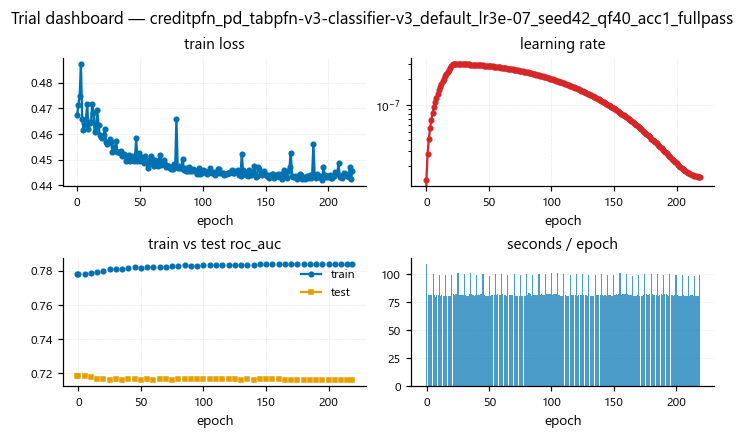

In [5]:
sink.save(plot_trial_dashboard(FOCUS_TRIAL, TRACK), 'trial_dashboard',
          caption="Four panels for the focus trial: training loss, learning-rate schedule, train and held-out monitoring metric, and wall-clock seconds, all against epoch.")

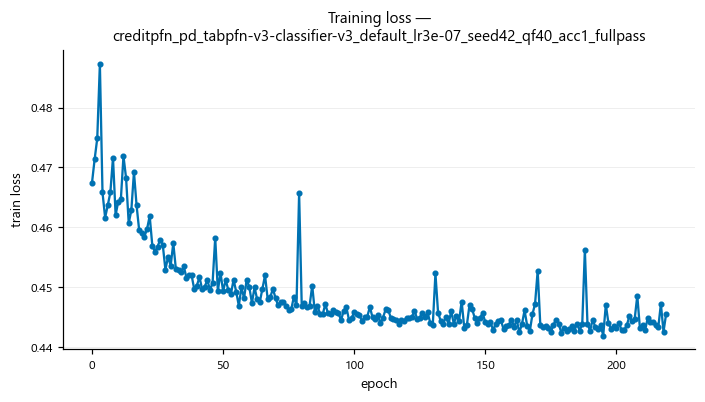

In [6]:
sink.save(plot_loss_curve(FOCUS_TRIAL, TRACK), 'loss_curve',
          caption="Training loss against epoch for the focus trial, averaged over the optimiser steps of each epoch.")

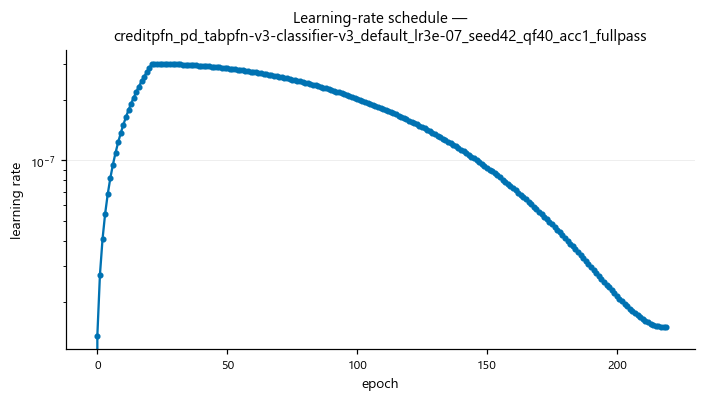

In [7]:
sink.save(plot_lr_schedule(FOCUS_TRIAL, TRACK), 'lr_schedule',
          caption="Learning rate against epoch for the focus trial: linear warmup followed by cosine decay to the configured floor.")

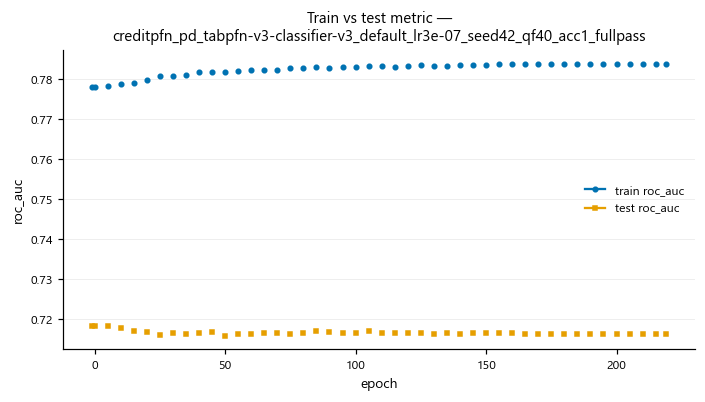

In [8]:
sink.save(plot_metric_curves(FOCUS_TRIAL, TRACK), 'metric_curves',
          caption="Monitoring metric against epoch for the focus trial, on the training datasets and on the held-out datasets, on twin axes. The monitor uses a fixed 2 000-row sample per dataset.")

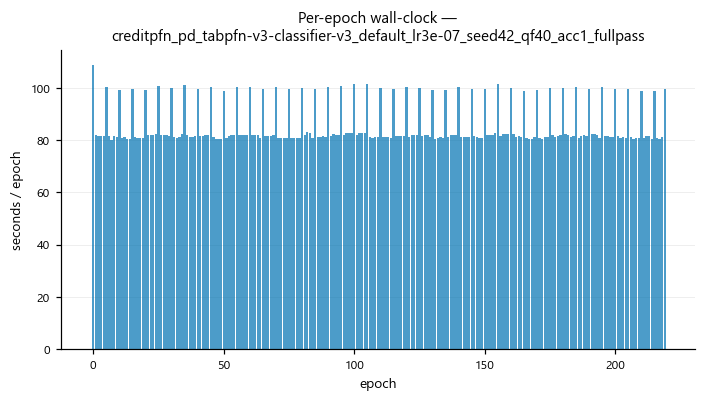

In [9]:
sink.save(plot_epoch_time(FOCUS_TRIAL, TRACK), 'epoch_time',
          caption="Wall-clock seconds per epoch for the focus trial.")

## 3 · Cross-trial overlays

Every trial on one axes. Colour = base checkpoint;
solid = no-LoRA, dashed = LoRA. Use these to spot regimes:

* If LoRA trials cluster well below no-LoRA ⇒ LoRA is hurting on
  this track and base.
* If one base sits clearly above the others throughout ⇒ pick that
  base as the headline checkpoint.
* If test_metric falls while train_metric keeps climbing ⇒ overfit
  starting; check the gap plot.

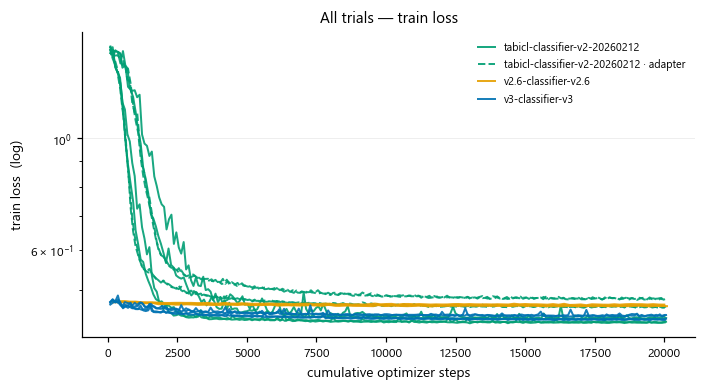

In [10]:
sink.save(plot_loss_overlay(TRACK), 'loss_overlay',
          caption="Training loss against epoch for every trial in the grid, one line per trial, coloured by base checkpoint and dashed for the adapter arm.")

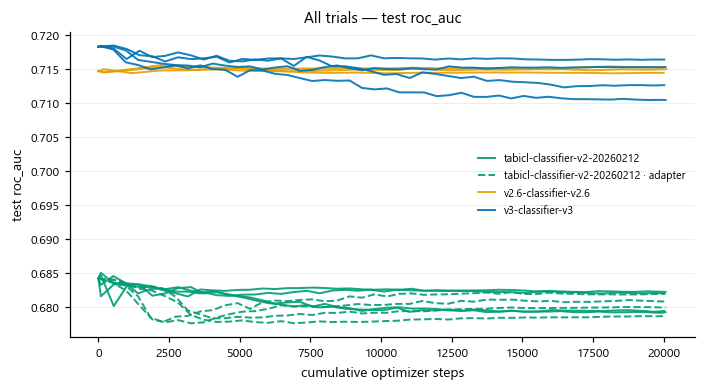

In [11]:
sink.save(plot_metric_overlay(TRACK, split='test'), 'metric_overlay',
          caption="Held-out monitoring metric against epoch for every trial, one line per trial, coloured by base checkpoint.")

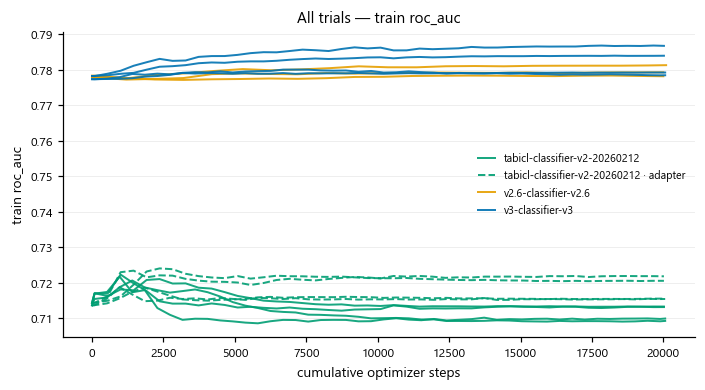

In [12]:
sink.save(plot_metric_overlay(TRACK, split='train'), 'metric_overlay',
          caption="Held-out monitoring metric against epoch for every trial, one line per trial, coloured by base checkpoint.")

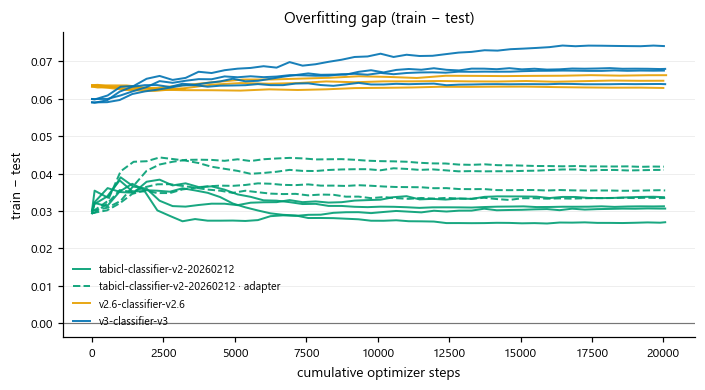

In [13]:
sink.save(plot_overfitting_diagnostic(TRACK), 'overfitting_diagnostic',
          caption="Training metric minus held-out metric against epoch, one line per trial. A rising line is the training corpus being fitted at the expense of unseen datasets.")

## 4 · Final-metric comparisons by hyperparameter

**`best_test_metric`** is the best test-set score the trial
achieved during training (max of `test_metric` for PD,
min for LGD).

**`final_test_metric`** is the last-epoch value (i.e. what the
checkpoint actually delivers on disk).

Swap the `metric=` kwarg below to view the latter instead.

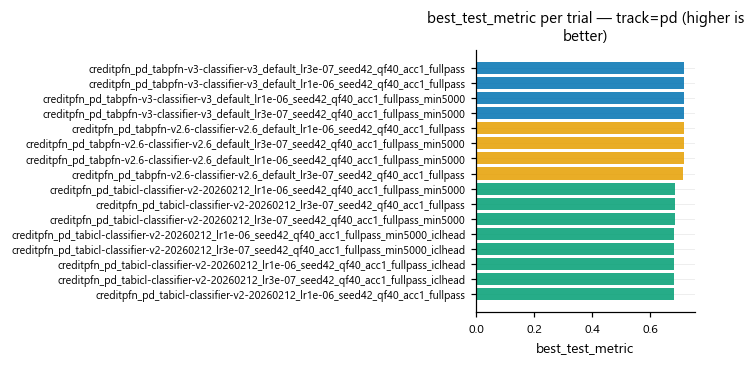

In [14]:
sink.save(plot_final_metric_bar(TRACK, metric='best_test_metric'), 'final_metric_bar',
          caption="Final monitoring metric per trial, sorted, one bar per trial, coloured by base checkpoint.")

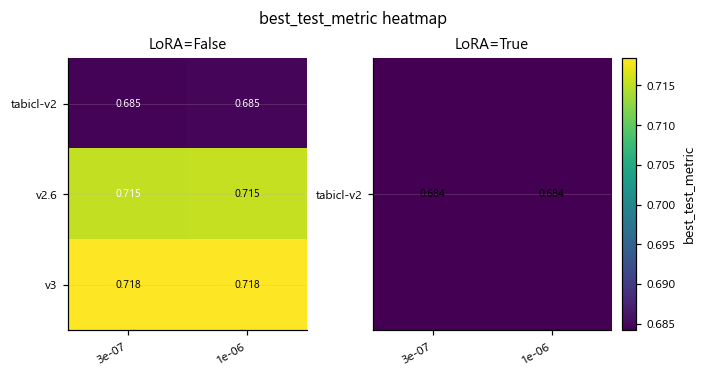

In [15]:
sink.save(plot_metric_heatmap(TRACK, metric='best_test_metric'), 'metric_heatmap',
          caption="Final monitoring metric over base checkpoint against learning rate, one panel per adaptation mode.")

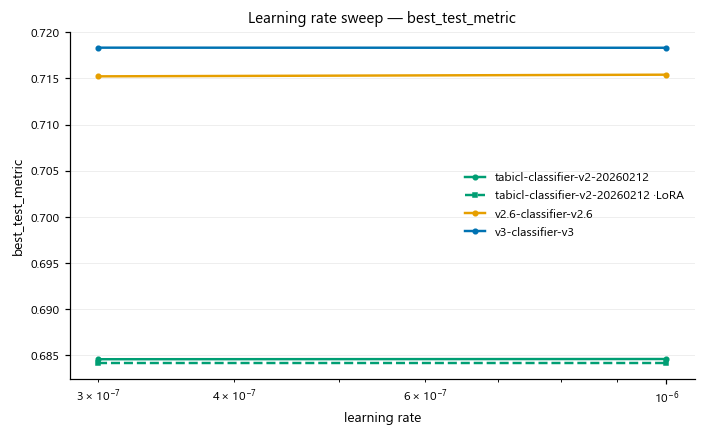

In [16]:
sink.save(plot_lr_effect(TRACK, metric='best_test_metric'), 'lr_effect',
          caption="Final monitoring metric against learning rate, one line per (base checkpoint, adaptation mode) pair.")

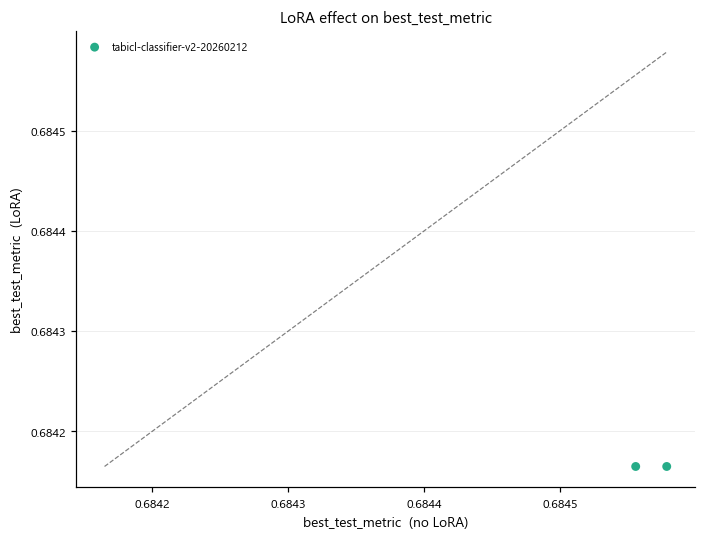

In [17]:
sink.save(plot_lora_effect(TRACK, metric='best_test_metric'), 'lora_effect',
          caption="Final monitoring metric of the full-finetuning arm against the adapter arm, paired within each (base, learning rate) pair. The diagonal marks equality.")

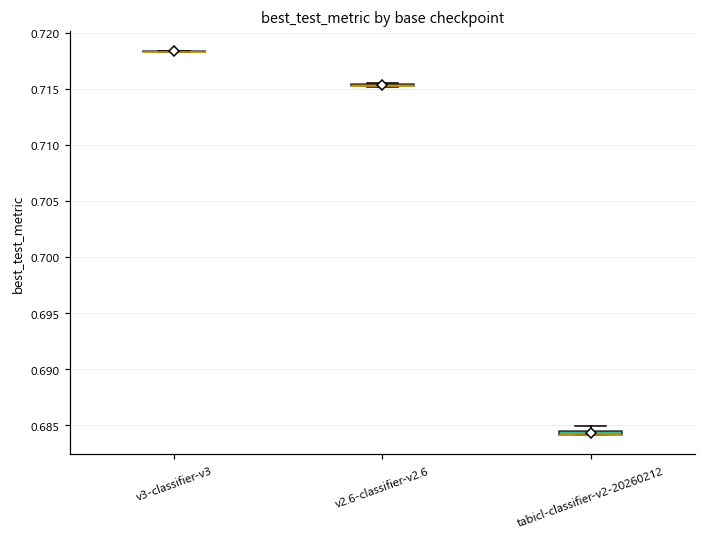

In [18]:
sink.save(plot_base_ranking(TRACK, metric='best_test_metric'), 'base_ranking',
          caption="Distribution of the final monitoring metric per base checkpoint, over all learning rates, adaptation modes and query fractions.")

## 5 · Time / accuracy trade-off

The Pareto-frontier-style scatter pairs **total training time** (x,
minutes) with the **final-epoch test metric** (y). A trial that
matches another's metric in less time pareto-dominates it.

The per-epoch bar plot underneath flags trials whose mean
seconds/epoch is unusually high — useful when one dataset's
chunk drags the whole epoch budget.

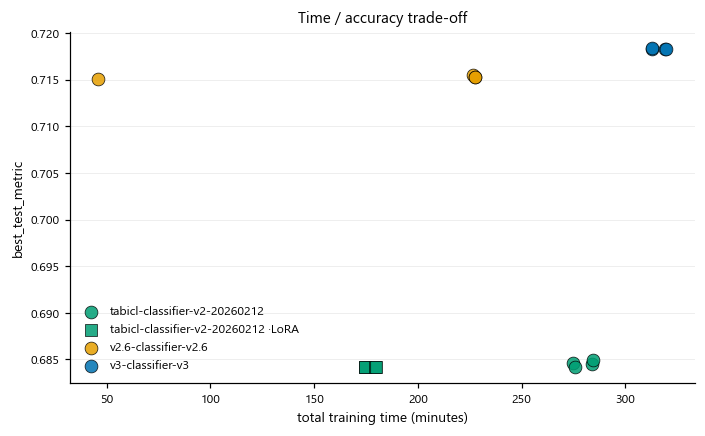

In [19]:
sink.save(plot_pareto_time_vs_metric(TRACK, metric='best_test_metric'), 'pareto_time_vs_metric',
          caption="Total training wall-clock against final monitoring metric, one point per trial, coloured by base checkpoint.")

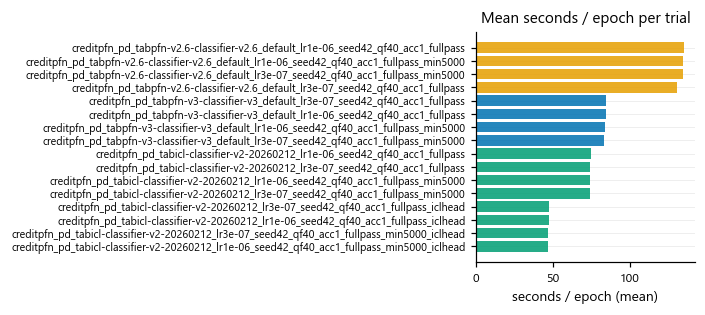

In [20]:
sink.save(plot_epoch_time_overlay(TRACK), 'epoch_time_overlay',
          caption="Median seconds per epoch per trial, one bar per trial, coloured by base checkpoint.")

## 6 · Convergence diagnostics

Where in the training budget does the best test metric appear?

* Most mass at < 30 % ⇒ early stop is leaving training cycles on
  the floor; consider shorter epochs or a stricter LR schedule.
* Most mass at > 80 % ⇒ trials are still improving when training
  ends; increase `cfg.train.epochs` before re-launching the sweep.

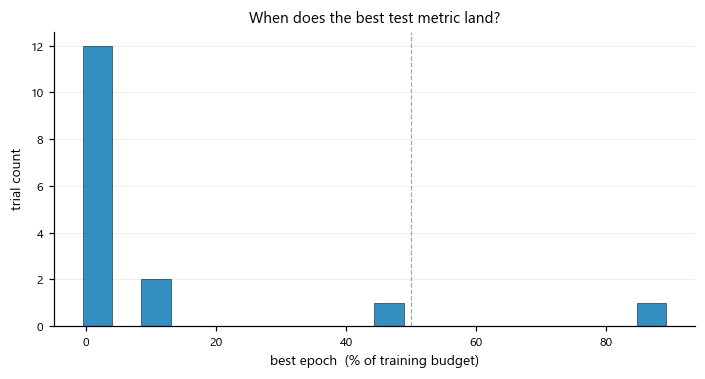

In [21]:
sink.save(plot_convergence_speed(TRACK), 'convergence_speed',
          caption="Distribution of the epoch at which each trial reached its best held-out monitoring metric.")

## 7 · Failures and leaderboard

`failed_trials()` surfaces any FAIL rows from the manifest with
their error string — most often a `CUDA OOM` from a too-large
`n_finetune_ctx_plus_query_samples`. The leaderboard at the end
is the canonical sorted view used to pick the headline
checkpoint for eval.

In [22]:
failures = failed_trials(TRACK)
if failures.empty:
    print('No failed trials. ✔')
else:
    display(failures)

,trial_name,base_short,learning_rate,use_lora,seed,elapsed_sec,status,error
0,creditpfn_pd_tabpfn-v2.6-classifier-v2.6_defau...,v2.6-classifier-v2.6,3.000000e-07,False,42,2763.60757,DIVERGED,diverged@epoch=14(loss_const)


In [23]:
trial_leaderboard(TRACK)

,trial_name,base_short,learning_rate,use_lora,seed,metric_name,best_test_metric,best_epoch,final_test_metric,final_train_metric,n_epochs,mean_epoch_sec,elapsed_sec,status
0,creditpfn_pd_tabpfn-v3-classifier-v3_default_l...,v3-classifier-v3,3.000000e-07,False,42,roc_auc,0.718406,5,0.716345,0.783878,221,84.851688,18776.262545,OK
1,creditpfn_pd_tabpfn-v3-classifier-v3_default_l...,v3-classifier-v3,1.000000e-06,False,42,roc_auc,0.718330,0,0.712579,0.786661,221,84.797521,18763.094521,OK
2,creditpfn_pd_tabpfn-v3-classifier-v3_default_l...,v3-classifier-v3,1.000000e-06,False,42,roc_auc,0.718306,0,0.710395,0.778381,229,83.684697,19184.714666,OK
3,creditpfn_pd_tabpfn-v3-classifier-v3_default_l...,v3-classifier-v3,3.000000e-07,False,42,roc_auc,0.718251,0,0.715241,0.779148,229,83.468159,19132.798028,OK
4,creditpfn_pd_tabpfn-v2.6-classifier-v2.6_defau...,v2.6-classifier-v2.6,1.000000e-06,False,42,roc_auc,0.715549,10,0.714919,0.781220,100,135.683663,13587.773968,OK
5,creditpfn_pd_tabpfn-v2.6-classifier-v2.6_defau...,v2.6-classifier-v2.6,3.000000e-07,False,42,roc_auc,0.715327,90,0.715213,0.778101,101,134.880397,13639.948063,OK
6,creditpfn_pd_tabpfn-v2.6-classifier-v2.6_defau...,v2.6-classifier-v2.6,1.000000e-06,False,42,roc_auc,0.715251,10,0.714391,0.779208,101,134.964105,13648.366457,OK
7,creditpfn_pd_tabpfn-v2.6-classifier-v2.6_defau...,v2.6-classifier-v2.6,3.000000e-07,False,42,roc_auc,0.715114,10,NaN,NaN,21,130.678804,2763.607570,DIVERGED
8,creditpfn_pd_tabicl-classifier-v2-20260212_lr1...,tabicl-classifier-v2-20260212,1.000000e-06,False,42,roc_auc,0.684992,0,0.679203,0.709862,229,74.429693,17057.338736,OK
9,creditpfn_pd_tabicl-classifier-v2-20260212_lr3...,tabicl-classifier-v2-20260212,3.000000e-07,False,42,roc_auc,0.684599,0,0.681970,0.713240,221,74.511380,16476.358803,OK


## 8. Did the model actually move?

`drift__<stage>` is $\|w - w_0\|$ over one top-level module of the model, recorded on
every monitored epoch. This is the plot that reframed run-5: a trial whose drift stays
flat near zero has **not trained**, so its "no effect" result says nothing about
continued pretraining. Below it, the per-dataset loss shows *which* tables the model is
learning — a corpus loss that falls while one dataset's loss rises is the model trading
one table off against the others.

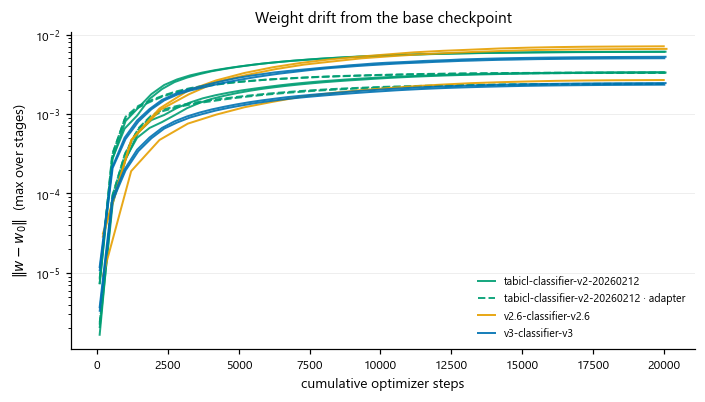

In [24]:
sink.save(plot_weight_drift(TRACK), 'weight_drift',
          caption="Distance of each trial's weights from its base checkpoint against epoch, on a log axis, taking the maximum over the model's top-level stages. One line per trial, coloured by base checkpoint.")


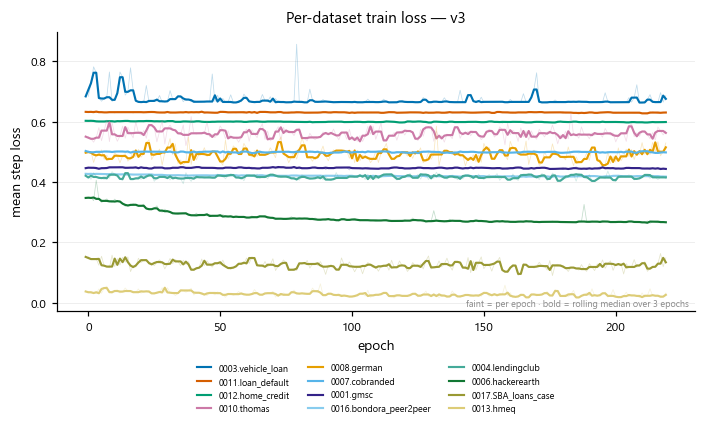

In [25]:
sink.save(plot_per_dataset_loss(FOCUS_TRIAL, TRACK), 'per_dataset_loss',
          caption="Mean training loss per dataset against epoch for the focus trial, one line per training dataset, ordered in the legend by final loss.")


## Summary

Everything above, as text. This is the block `src/utils/run_notebooks.py`
collects into `output/All_Results.md`, so it has to stand on its own: section
order follows this notebook's, and every figure's headline number is restated
here rather than living only inside a PDF.

In [26]:
from src.visualize import summaries

print(summaries.training_summary(TRACK))
print()
print(sink.summary())

  1.0. PD TRAINING
  continued pretraining — what the sweep did, not whether it helped


1. Trials
---------
  trials           : 16
    OK             15
    DIVERGED       1
    DIVERGED: checkpoints/tabpfn-v2.6-classifier-v2.6_default.ckpt lr=3e-07 reason=loss_const

2. Budget actually realised
---------------------------
  optimizer steps  4060 - 20097
  epochs           99 - 228
  steps/epoch      88 - 203
  steps per corpus arm: {0: (4060, 20097), 5000: (20000, 20064)}
  passes over corpus : 20 - 228   (Garg 2025: ~280 over 71 tables)

3. The corpus this sweep trained on
-----------------------------------
  train datasets     [9, 12]
  held-out datasets  5
  train rows         [2154278, 2158604]
  held-out rows      328281
    min_train_rows=0     -> 12 train datasets
    min_train_rows=5000  -> 9 train datasets
  train ids (12): 0001.gmsc, 0003.vehicle_loan, 0004.lendingclub, 0006.hackerearth, 0007.cobranded, 0008.german ...
  held-out ids (5): 0002.taiwan_creditcard, 0005.myho